# Environment Retention Analysis

Demonstrate kick velocity distributions, escape velocity sampling, and retention probability computation for all predefined environments.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from gwGenealogy.environments import (
    ENVIRONMENTS,
    sample_escape_speed,
    sample_multi_escape_speed,
    compute_environment_retention,
    compute_environment_cumulative_retention,
    compute_multi_environment_cumulative_retention,
)

## 1. Generate kick velocities

Model kicks as the sum of two components:
- Beta distribution scaled to [0, 1000] km/s (low-kick population)
- Gaussian truncated to [0, 2500] km/s (high-kick tail)

In [2]:
rng = np.random.default_rng(42)
n_samples = 50000

# Beta component: Beta(2, 5) scaled to [0, 1000] km/s
v_beta = rng.beta(2, 5, size=n_samples) * 1000.0

# Gaussian component: mean=200, std=300, clipped to [0, 2500]
v_gauss = np.clip(rng.normal(200, 300, size=n_samples), 0, 2500)

# Total kick = sum of both components
v_kick = v_beta + v_gauss
v_kick = np.clip(v_kick, 0, None)

print(f"Kick velocities: median={np.median(v_kick):.1f} km/s, "
      f"5th={np.percentile(v_kick,5):.1f}, 95th={np.percentile(v_kick,95):.1f} km/s")

Kick velocities: median=499.1 km/s, 5th=124.5, 95th=1046.4 km/s


## 2. Plot kick velocity histogram

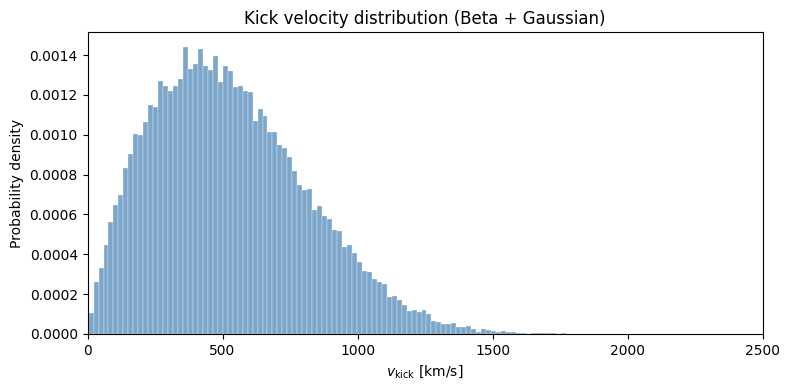

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(v_kick, bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='white', lw=0.3)
ax.set_xlabel('$v_{\\mathrm{kick}}$ [km/s]')
ax.set_ylabel('Probability density')
ax.set_title('Kick velocity distribution (Beta + Gaussian)')
ax.set_xlim(0, 2500)
plt.tight_layout()
plt.show()

## 3. Sample and plot escape velocities for all environments

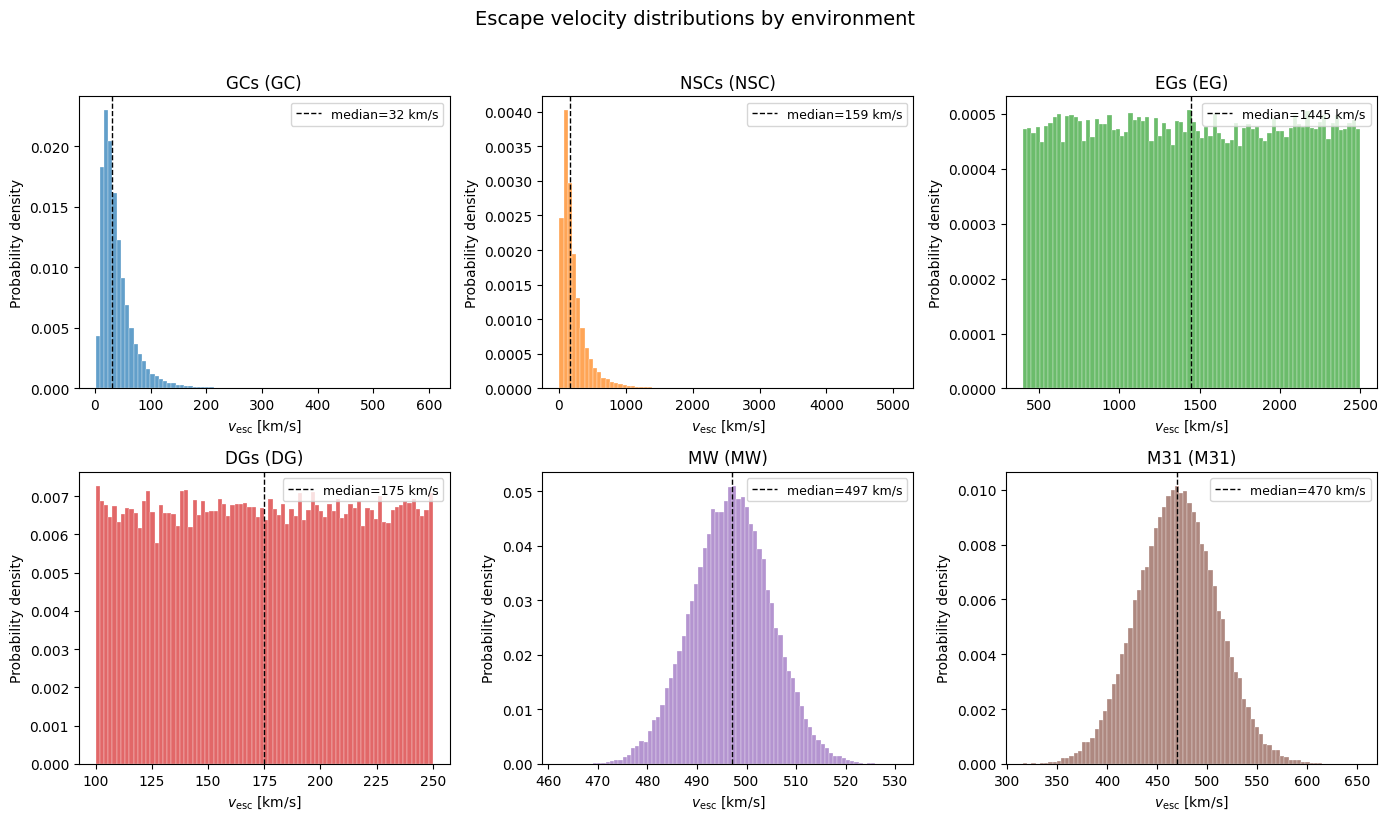

In [4]:
v_esc_samples = sample_multi_escape_speed(n_samples, seed=123)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

colors = {'GC': 'C0', 'NSC': 'C1', 'EG': 'C2', 'DG': 'C3', 'MW': 'C4', 'M31': 'C5'}

for i, (name, v_esc) in enumerate(v_esc_samples.items()):
    ax = axes[i]
    ax.hist(v_esc, bins=80, density=True, alpha=0.7, color=colors[name], edgecolor='white', lw=0.3)
    ax.set_title(f"{ENVIRONMENTS[name]['label']} ({name})")
    ax.set_xlabel('$v_{\\mathrm{esc}}$ [km/s]')
    ax.set_ylabel('Probability density')
    med = np.median(v_esc)
    ax.axvline(med, color='k', ls='--', lw=1, label=f'median={med:.0f} km/s')
    ax.legend(fontsize=9)

plt.suptitle('Escape velocity distributions by environment', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Compute per-kick retention $p_{\mathrm{ret}}$ and plot

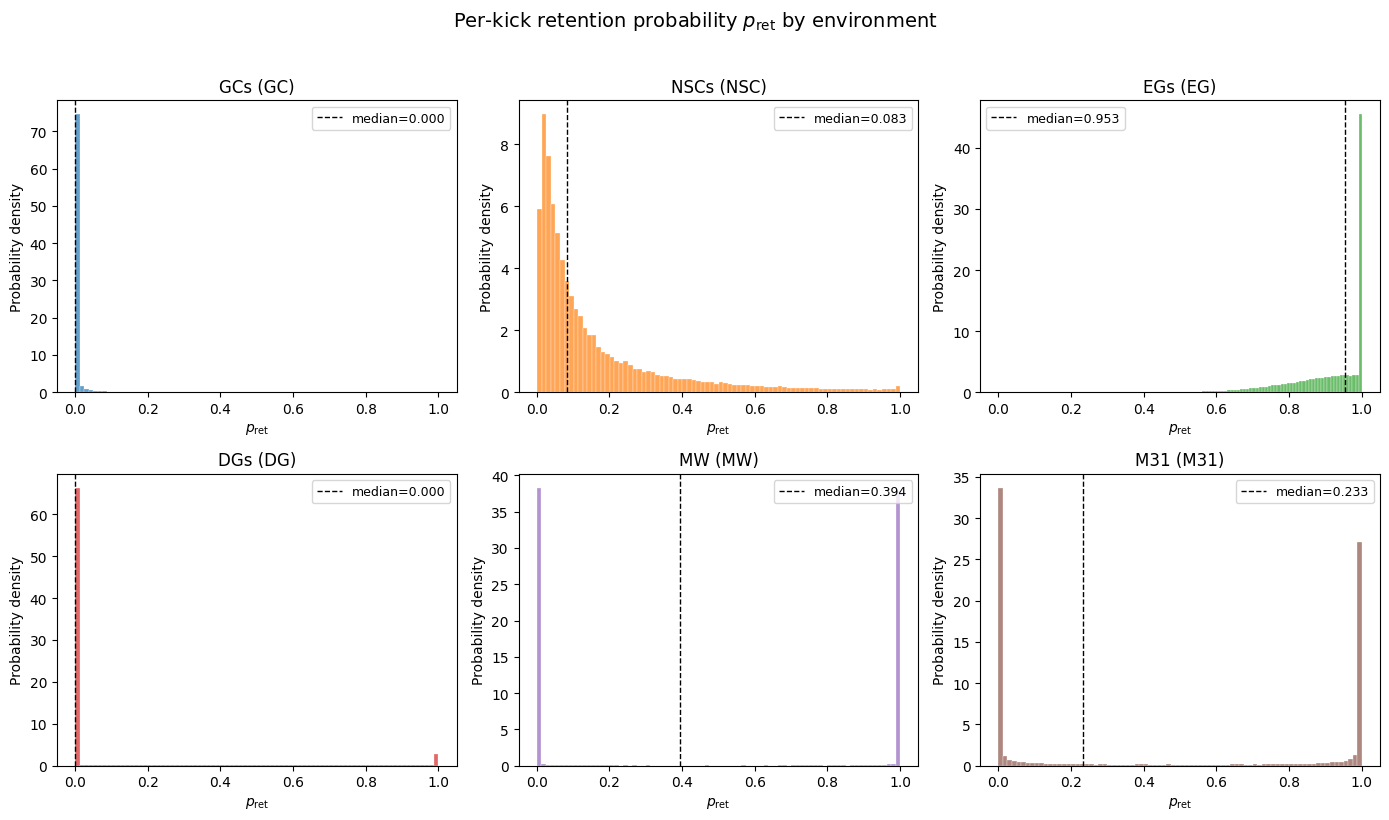

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, (name, env) in enumerate(ENVIRONMENTS.items()):
    ax = axes[i]
    p_ret = compute_environment_retention(v_kick, env)
    
    ax.hist(p_ret, bins=80, density=True, alpha=0.7, color=colors[name], edgecolor='white', lw=0.3)
    ax.set_title(f"{env['label']} ({name})")
    ax.set_xlabel('$p_{\\mathrm{ret}}$')
    ax.set_ylabel('Probability density')
    ax.set_xlim(-0.05, 1.05)
    med = np.median(p_ret)
    ax.axvline(med, color='k', ls='--', lw=1, label=f'median={med:.3f}')
    ax.legend(fontsize=9)

plt.suptitle('Per-kick retention probability $p_{\\mathrm{ret}}$ by environment', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Compute integrated retention $P_{\mathrm{ret}}$

In [6]:
P_ret = compute_multi_environment_cumulative_retention(v_kick)

print("Integrated retention fraction P_ret:")
print("-" * 35)
for name, val in P_ret.items():
    label = ENVIRONMENTS[name]['label']
    print(f"  {label:5s} ({name:3s}): P_ret = {val:.4f}")

Integrated retention fraction P_ret:
-----------------------------------
  GCs   (GC ): P_ret = 0.0089
  NSCs  (NSC): P_ret = 0.1622
  EGs   (EG ): P_ret = 0.9112
  DGs   (DG ): P_ret = 0.0966
  MW    (MW ): P_ret = 0.4973
  M31   (M31): P_ret = 0.4609


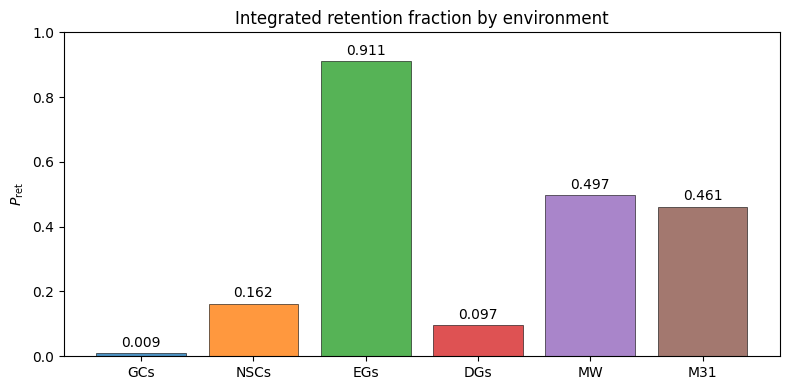

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
names = list(P_ret.keys())
vals = [P_ret[n] for n in names]
labels = [ENVIRONMENTS[n]['label'] for n in names]
bar_colors = [colors[n] for n in names]

ax.bar(labels, vals, color=bar_colors, edgecolor='k', lw=0.5, alpha=0.8)
ax.set_ylabel('$P_{\\mathrm{ret}}$')
ax.set_title('Integrated retention fraction by environment')
ax.set_ylim(0, 1)

for j, (lbl, v) in enumerate(zip(labels, vals)):
    ax.text(j, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 6. $p_{\mathrm{ret}}$ vs $v_{\mathrm{kick}}$ curves

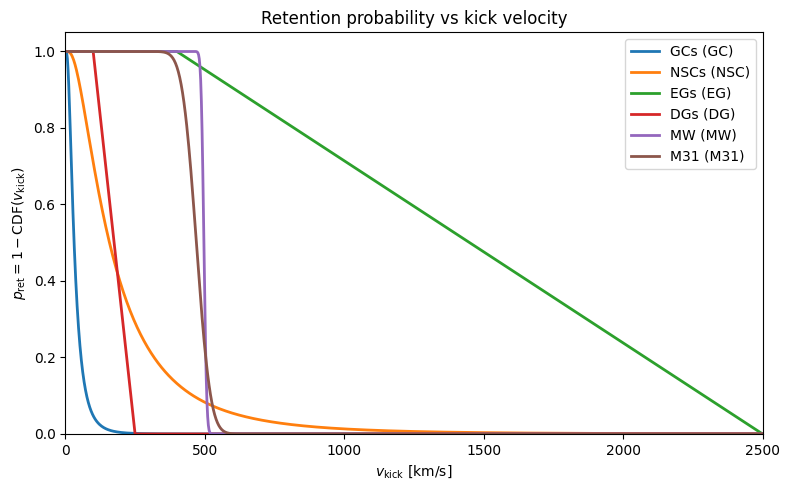

In [8]:
v_grid = np.linspace(0, 2500, 1000)

fig, ax = plt.subplots(figsize=(8, 5))
for name, env in ENVIRONMENTS.items():
    p_ret_curve = compute_environment_retention(v_grid, env)
    ax.plot(v_grid, p_ret_curve, label=f"{env['label']} ({name})", color=colors[name], lw=2)

ax.set_xlabel('$v_{\\mathrm{kick}}$ [km/s]')
ax.set_ylabel('$p_{\\mathrm{ret}} = 1 - \\mathrm{CDF}(v_{\\mathrm{kick}})$')
ax.set_title('Retention probability vs kick velocity')
ax.legend()
ax.set_xlim(0, 2500)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()